In [1]:
# import the stuff you need. Pytorch is already installed on Google colab
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchinfo import summary
from huggingface_hub import hf_hub_download

c:\Users\hynda\OneDrive\Documents\Applied-Deep-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Constants
DATA_PATH = "dataset"

#Hyperparams
EPOCHS = 300
LR = 1e-3
BATCH_SIZE = 64

In [3]:
# # Download dataset
# hf_hub_download(repo_id="simbaswe/galah4", filename="labels.npy", repo_type="dataset", local_dir=".")
# hf_hub_download(repo_id="simbaswe/galah4", filename="spectra.npy", repo_type="dataset", local_dir=".")

In [4]:
spectra = np.load(f"{DATA_PATH}/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{DATA_PATH}/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]

In [5]:
# normalize the spectra
spectra = np.log(np.maximum(spectra, 0.2))

In [6]:
print("Spectra:", spectra.shape)
print("Labels:", labels.shape)

Spectra: (8914, 16384)
Labels: (8914, 3)


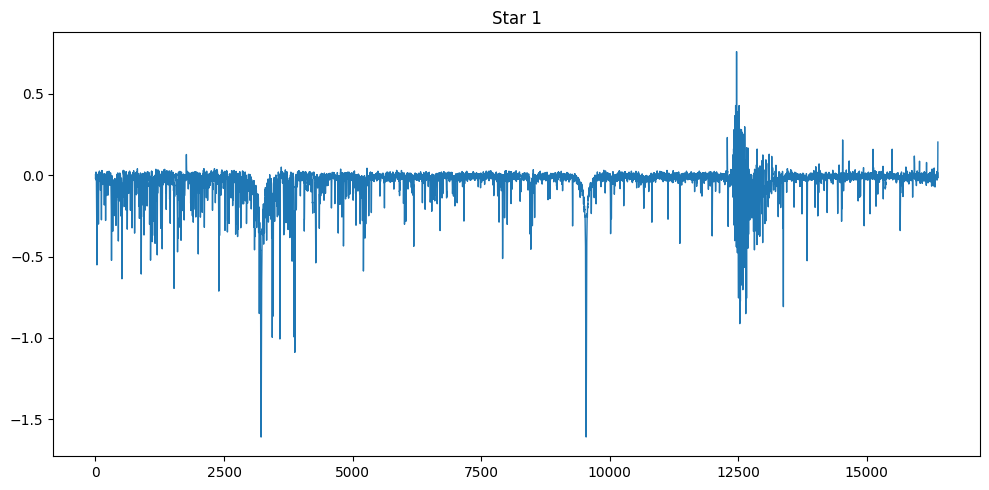

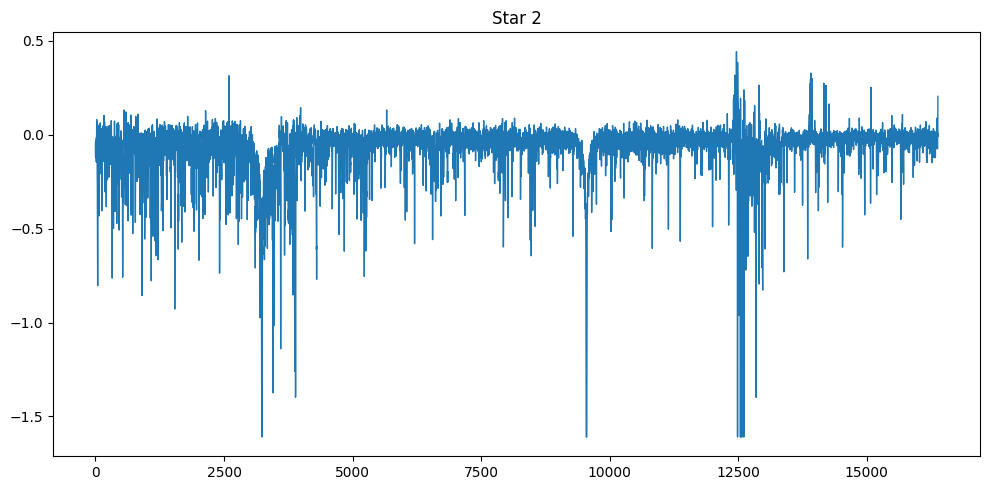

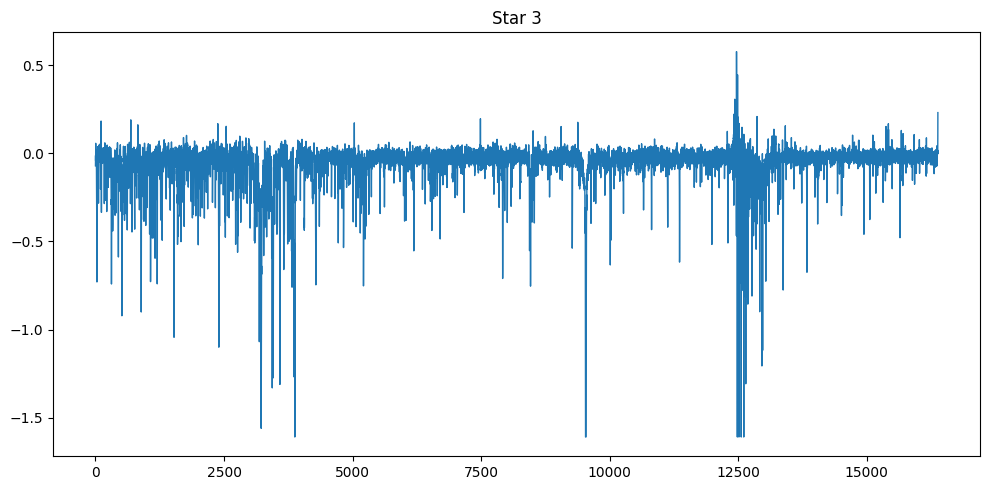

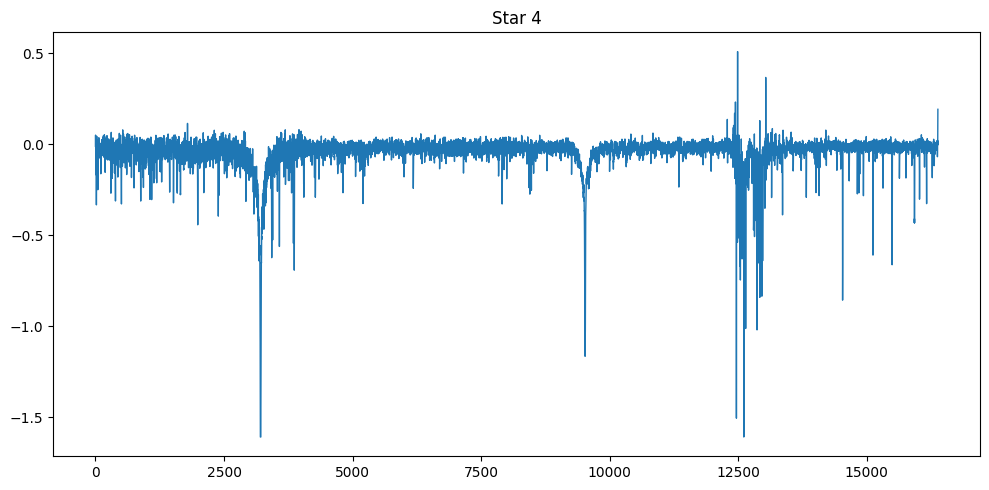

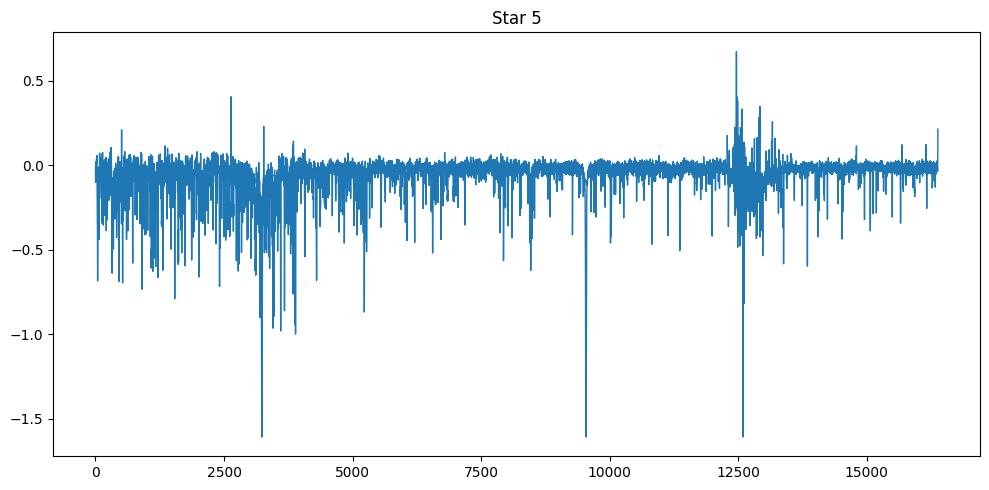

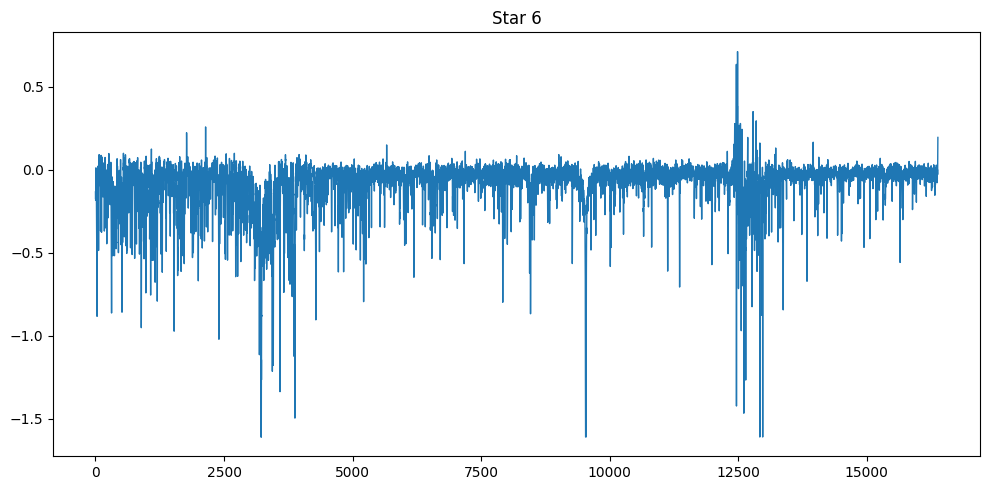

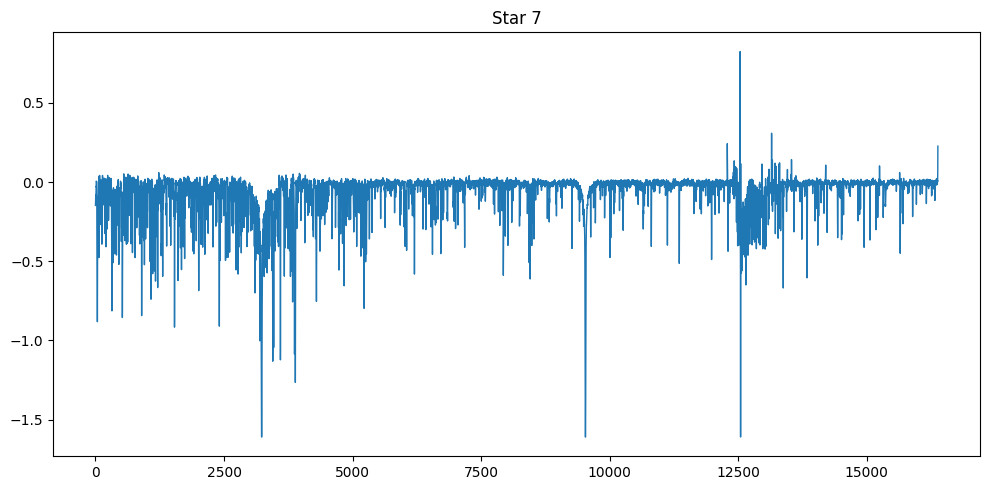

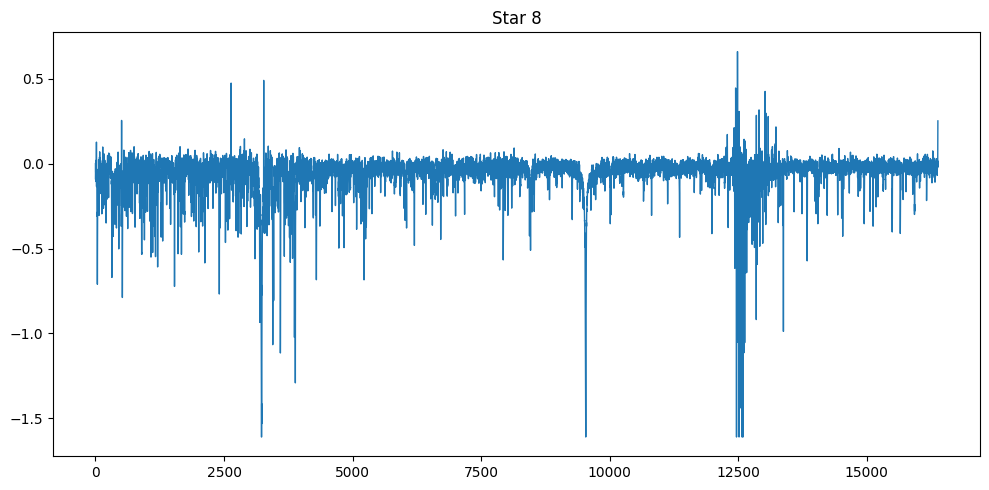

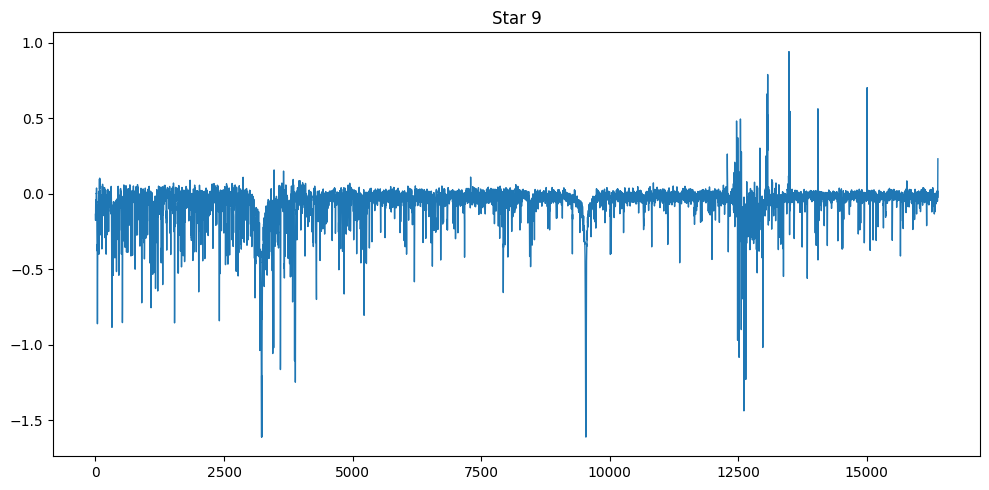

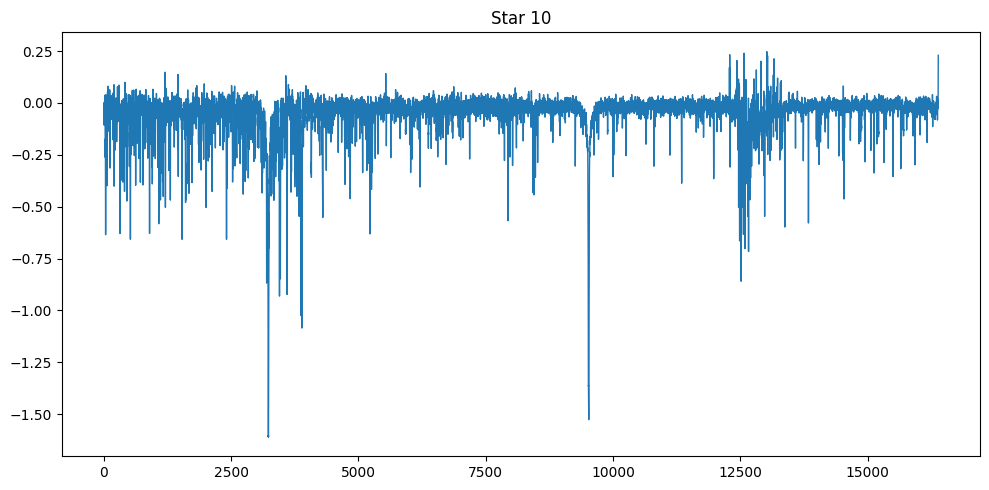

In [7]:
%matplotlib inline
# plot a few spectra
for i in range(10):
  fig, ax = plt.subplots(1, 1, figsize=(10, 5))
  ax.plot(spectra[i], lw=1)
  ax.set_title(f"Star {i+1}")
  plt.tight_layout()

In [8]:
# Splitting into train, val and test datasets

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(spectra, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Shapes of train, test and val X : {X_train.shape}, {X_val.shape}, {X_test.shape}")
print(f"Shapes of train, test and val y : {y_train.shape}, {y_val.shape}, {y_test.shape}")

Shapes of train, test and val X : (6239, 16384), (1337, 16384), (1338, 16384)
Shapes of train, test and val y : (6239, 3), (1337, 3), (1338, 3)


In [9]:
mean = y_train.mean(axis=0)
std = y_train.std(axis=0)

y_train = (y_train - mean) / std
y_val   = (y_val   - mean) / std
y_test  = (y_test  - mean) / std

In [10]:
class SpectraDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SpectraDataset(X_train, y_train)
val_dataset = SpectraDataset(X_val, y_val)
test_dataset = SpectraDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [11]:
class SpectraCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        return self.fc(x)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


model = SpectraCNN().to(device)
print(summary(model, input_size=(1, 16384)))
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',factor=0.5, patience=5)
criterion = nn.MSELoss()

cuda
Layer (type:depth-idx)                   Output Shape              Param #
SpectraCNN                               [1, 3]                    --
├─Sequential: 1-1                        [1, 64, 2048]             --
│    └─Conv1d: 2-1                       [1, 16, 16384]            128
│    └─ReLU: 2-2                         [1, 16, 16384]            --
│    └─MaxPool1d: 2-3                    [1, 16, 8192]             --
│    └─Conv1d: 2-4                       [1, 32, 8192]             3,616
│    └─ReLU: 2-5                         [1, 32, 8192]             --
│    └─MaxPool1d: 2-6                    [1, 32, 4096]             --
│    └─Conv1d: 2-7                       [1, 64, 4096]             14,400
│    └─ReLU: 2-8                         [1, 64, 4096]             --
│    └─MaxPool1d: 2-9                    [1, 64, 2048]             --
├─AdaptiveAvgPool1d: 1-2                 [1, 64, 1]                --
├─Sequential: 1-3                        [1, 3]                    --
│ 

In [13]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(X)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            loss = criterion(preds, y)
            total_loss += loss.item()

    return total_loss / len(loader)

In [14]:
train_losses, val_losses = [], []

best_val_loss = float('inf')
patience = 10
counter = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss = eval_epoch(model, val_loader)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    if epoch%10==9:
        print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 10: Train=0.6540, Val=0.6996
Epoch 20: Train=0.5168, Val=0.5685
Epoch 30: Train=0.3940, Val=0.4230
Epoch 40: Train=0.3106, Val=0.2981
Epoch 50: Train=0.1826, Val=0.1907
Epoch 60: Train=0.1398, Val=0.1409
Epoch 70: Train=0.1311, Val=0.1436
Epoch 80: Train=0.1052, Val=0.1122
Epoch 90: Train=0.0946, Val=0.0959
Epoch 100: Train=0.0861, Val=0.0880
Epoch 110: Train=0.0777, Val=0.0874
Epoch 120: Train=0.0738, Val=0.0858
Epoch 130: Train=0.0705, Val=0.0789
Epoch 140: Train=0.0692, Val=0.0772
Epoch 150: Train=0.0677, Val=0.0756
Epoch 160: Train=0.0649, Val=0.0714
Epoch 170: Train=0.0642, Val=0.0709
Epoch 180: Train=0.0643, Val=0.0709
Epoch 190: Train=0.0642, Val=0.0703
Epoch 200: Train=0.0636, Val=0.0699
Epoch 210: Train=0.0630, Val=0.0709
Epoch 220: Train=0.0628, Val=0.0698
Epoch 230: Train=0.0629, Val=0.0697
Early stopping triggered


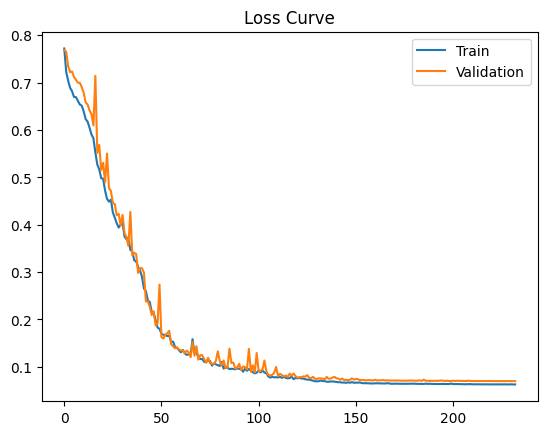

In [15]:
plt.plot(train_losses[1:], label="Train")
plt.plot(val_losses[1:], label="Validation")
plt.legend()
plt.title("Loss Curve")
plt.show()


In [16]:
model.load_state_dict(torch.load("best_model.pth"))

test_loss = eval_epoch(model, test_loader)
print("Final Test Loss:", test_loss)

Final Test Loss: 0.06576144996853102


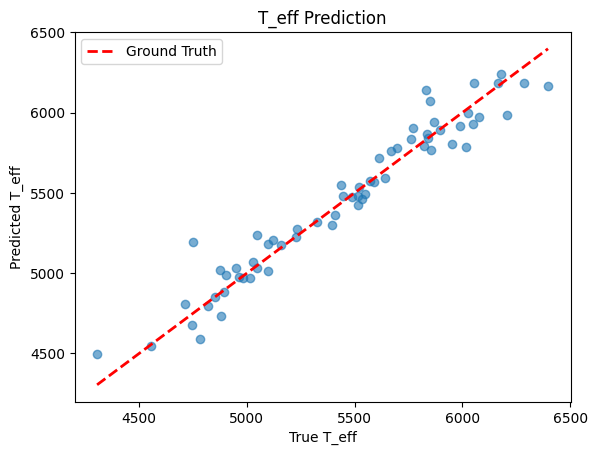

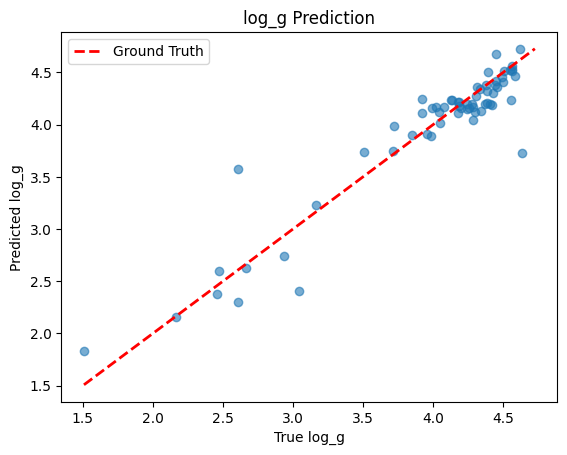

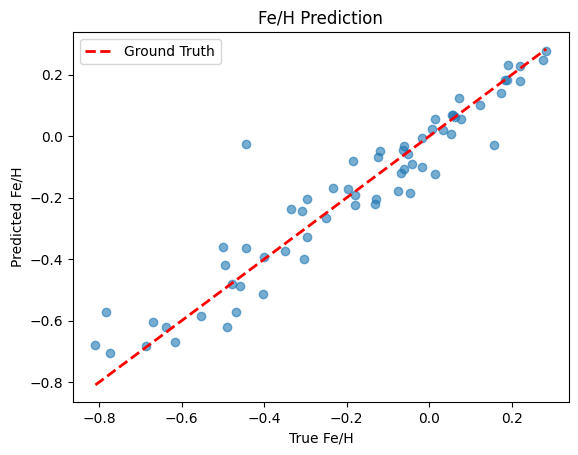

In [24]:
model.eval()

X_sample, y_true = next(iter(test_loader))

with torch.no_grad():
    preds = model(X_sample.to(device)).cpu().numpy()

y_true = y_true.numpy()

preds_real = preds * std + mean
y_true_real = y_true * std + mean

labels_names = ["T_eff", "log_g", "Fe/H"]

for i in range(3):
    plt.scatter(y_true_real[:, i], preds_real[:, i], alpha = 0.6) #true value v/s predicted value

    min_val = min(y_true_real[:, i].min(), preds_real[:, i].min())
    max_val = max(y_true_real[:, i].max(), preds_real[:, i].max())

    # Plot y = x line
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label = "Ground Truth")


    plt.xlabel(f"True {labels_names[i]}")
    plt.ylabel(f"Predicted {labels_names[i]}")
    plt.title(f"{labels_names[i]} Prediction")
    plt.legend()
    plt.show()